<a href="https://colab.research.google.com/github/beasghoshdastidar/AI-LAB-/blob/main/checkroutes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DFS ROUTE CHECKING
Route A → C: Exists
Route A → E: Does not exist

CONNECTED COMPONENTS
Component 1: ['A', 'B', 'C']
Component 2: ['D', 'E']
Component 3: ['F', 'G']


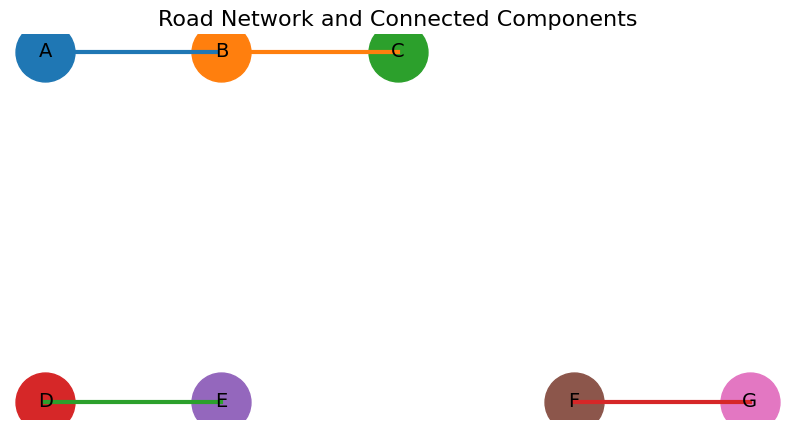

In [1]:
import matplotlib.pyplot as plt

# -----------------------------
# Road network
# -----------------------------
graph = {
    'A': ['B'],
    'B': ['A', 'C'],
    'C': ['B'],
    'D': ['E'],
    'E': ['D'],
    'F': ['G'],
    'G': ['F']
}


# -----------------------------
# DFS Route Checking
# -----------------------------
def route_exists(graph, start, destination, visited=None):

    if visited is None:
        visited = set()

    if start == destination:
        return True

    visited.add(start)

    for neighbour in graph[start]:

        if neighbour not in visited:

            if route_exists(
                graph,
                neighbour,
                destination,
                visited
            ):
                return True

    return False


# -----------------------------
# DFS Connected Components
# -----------------------------
def dfs_component(graph, city, visited, component):

    visited.add(city)
    component.append(city)

    for neighbour in graph[city]:

        if neighbour not in visited:
            dfs_component(
                graph,
                neighbour,
                visited,
                component
            )


def connected_components(graph):

    visited = set()
    components = []

    for city in graph:

        if city not in visited:

            component = []

            dfs_component(
                graph,
                city,
                visited,
                component
            )

            components.append(component)

    return components


# -----------------------------
# Route Results
# -----------------------------

print("DFS ROUTE CHECKING")
print("=" * 40)

print(
    "Route A → C:",
    "Exists" if route_exists(graph, 'A', 'C')
    else "Does not exist"
)

print(
    "Route A → E:",
    "Exists" if route_exists(graph, 'A', 'E')
    else "Does not exist"
)


# -----------------------------
# Connected Components
# -----------------------------

components = connected_components(graph)

print("\nCONNECTED COMPONENTS")
print("=" * 40)

for i, component in enumerate(components, 1):
    print(f"Component {i}: {component}")


# -----------------------------
# Visual Diagram
# -----------------------------

positions = {
    'A': (0, 1),
    'B': (1, 1),
    'C': (2, 1),

    'D': (0, -1),
    'E': (1, -1),

    'F': (3, -1),
    'G': (4, -1)
}

edges = [
    ('A', 'B'),
    ('B', 'C'),
    ('D', 'E'),
    ('F', 'G')
]

plt.figure(figsize=(10, 5))

# Draw roads
for city1, city2 in edges:

    x1, y1 = positions[city1]
    x2, y2 = positions[city2]

    plt.plot(
        [x1, x2],
        [y1, y2],
        linewidth=3
    )


# Draw cities
for city, (x, y) in positions.items():

    plt.scatter(
        x, y,
        s=1800
    )

    plt.text(
        x, y,
        city,
        ha='center',
        va='center',
        fontsize=14
    )


plt.title(
    "Road Network and Connected Components",
    fontsize=16
)

plt.axis('off')
plt.show()